# Proyecto ML - Clasificación de comentarios acusatorios

Este notebook construye y evalúa modelos de aprendizaje automático para detectar comentarios o preguntas acusatorias. El problema es relevante porque, en contextos de contratación o revisión documental, una gran cantidad de preguntas puede ocultar señales de inconformidad, atribución de culpa o cuestionamientos que requieren atención prioritaria.

La variable objetivo es `final_pregunta_isAcusatoria`, donde `1` indica comentario acusatorio y `0` indica comentario no acusatorio. Todo el flujo está contenido en este único notebook y usa únicamente el archivo local `dataset.xlsx`.

In [1]:
# PROMPT usado con ChatGPT:
# "Revisa y reconstruye en un solo notebook un proyecto de ML para clasificar comentarios
# acusatorios. Debe incluir introducción, EDA, feature extraction, feature selection tipo
# filtro, pipelines de sklearn, optimización con repeated k-fold CV, t-SNE antes de
# clasificar, comparación estadística entre dos modelos optimizados, revisión de data
# leakage, conclusiones y referencias IEEE."

import os
import re
import sys
import time
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
TEXT_COL = "pregunta"
TARGET = "final_pregunta_isAcusatoria"
VOTES_COL = "sum_pregunta_isAcusatoria"

print("Ejecutado con intérprete externo:", sys.executable)
print("Versión de Python:", sys.version.split()[0])
print("Nota: el notebook conserva outputs ya calculados; al re-ejecutar, usa el kernel Python disponible en el equipo.")

Ejecutado con intérprete externo: C:\Python314\python.exe
Versión de Python: 3.14.3
Nota: el notebook conserva outputs ya calculados; al re-ejecutar, usa el kernel Python disponible en el equipo.


## 1. Carga del dataset

Se carga el archivo local `dataset.xlsx`. No se usa descarga externa para mantener reproducibilidad con el dataset entregado.

In [2]:
df = pd.read_excel("dataset.xlsx", engine="openpyxl")

required_cols = {TEXT_COL, TARGET, VOTES_COL}
missing = required_cols.difference(df.columns)
if missing:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing)}")

print(f"Shape del dataset: {df.shape}")
print("Columnas:", list(df.columns))
print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))
print("\nValores faltantes:")
display(df.isna().sum().to_frame("n_missing"))
print("\nPrimeras filas:")
display(df.head())

Shape del dataset: (5005, 5)
Columnas: ['contract_id', 'pregunta_id', 'pregunta', 'sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']

Tipos de datos:

Valores faltantes:

Primeras filas:


,tipo
contract_id,int64
pregunta_id,int64
pregunta,str
sum_pregunta_isAcusatoria,int64
final_pregunta_isAcusatoria,int64


,n_missing
contract_id,0
pregunta_id,0
pregunta,0
sum_pregunta_isAcusatoria,0
final_pregunta_isAcusatoria,0


,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0
3,682361,18263,Se puede ofertar un equipo que utilice cubetas...,0,0
4,1224444,18782,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0,0


## 2. Exploratory Data Analysis (EDA)

Se revisa el balance de clases, las longitudes de texto, los votos de anotadores y los duplicados. Esto permite entender el grado de desbalance y posibles riesgos antes de modelar.

Distribución de clases:
  Clase 0 (No acusatoria): 4858 (97.06%)
  Clase 1 (Acusatoria): 147 (2.94%)
Ratio clase 0:1 = 33.0:1


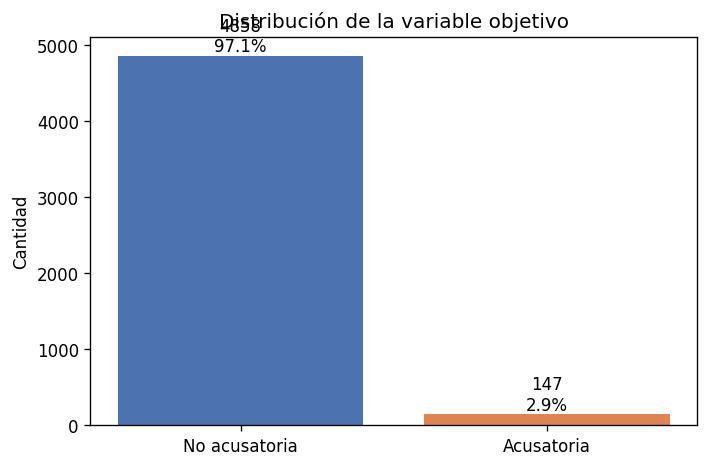

In [3]:
counts = df[TARGET].value_counts().sort_index()
percentages = df[TARGET].value_counts(normalize=True).sort_index() * 100

print("Distribución de clases:")
for label in [0, 1]:
    name = "No acusatoria" if label == 0 else "Acusatoria"
    print(f"  Clase {label} ({name}): {counts[label]} ({percentages[label]:.2f}%)")
print(f"Ratio clase 0:1 = {counts[0] / counts[1]:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["No acusatoria", "Acusatoria"], counts.values, color=["#4C72B0", "#DD8452"])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value}\n{value/counts.sum():.1%}", ha="center", va="bottom")
ax.set_title("Distribución de la variable objetivo")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

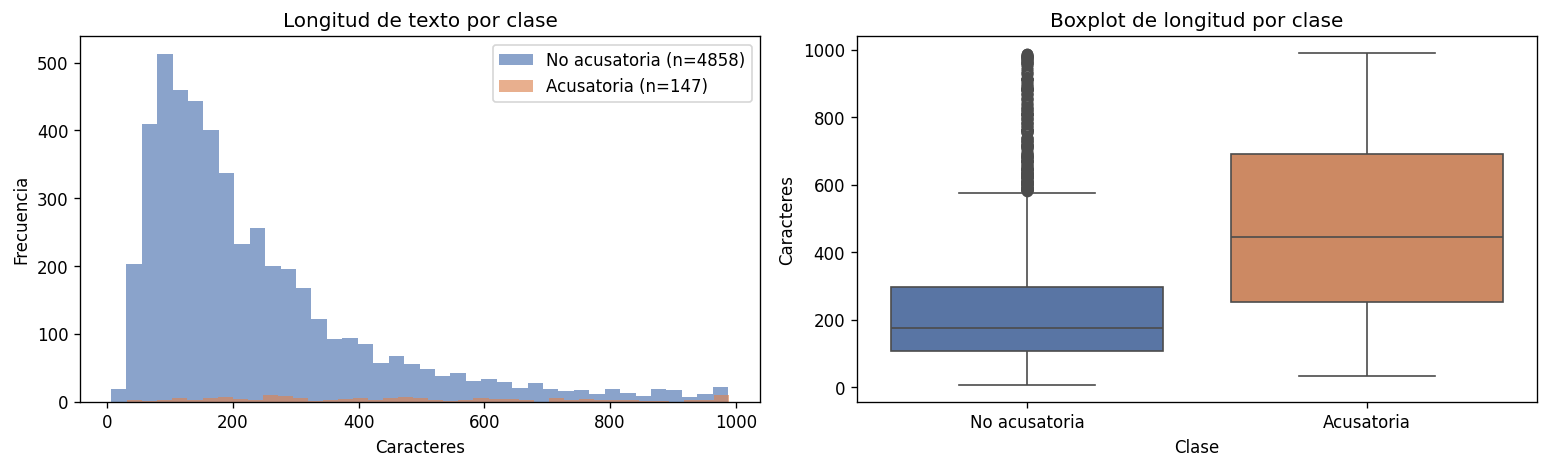

,count,mean,std,min,25%,50%,75%,max
final_pregunta_isAcusatoria,,,,,,,,
0,4858.0,234.23,182.38,6.0,108.0,176.0,296.0,988.0
1,147.0,477.44,266.40,32.0,253.0,446.0,690.0,990.0


In [4]:
df_eda = df.copy()
df_eda["longitud_texto"] = df_eda[TEXT_COL].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, color, name in [(0, "#4C72B0", "No acusatoria"), (1, "#DD8452", "Acusatoria")]:
    subset = df_eda.loc[df_eda[TARGET] == label, "longitud_texto"]
    axes[0].hist(subset, bins=40, alpha=0.65, label=f"{name} (n={len(subset)})", color=color)
axes[0].set_title("Longitud de texto por clase")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

sns.boxplot(x=TARGET, y="longitud_texto", data=df_eda, hue=TARGET, palette=["#4C72B0", "#DD8452"], legend=False, ax=axes[1])
axes[1].set_xticks([0, 1], ["No acusatoria", "Acusatoria"])
axes[1].set_title("Boxplot de longitud por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Caracteres")
plt.tight_layout()
plt.show()

display(df_eda.groupby(TARGET)["longitud_texto"].describe().round(2))

Valores únicos de suma de votos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Tabla cruzada entre votos de anotadores y etiqueta final:


final_pregunta_isAcusatoria,0,1,Total
sum_pregunta_isAcusatoria,,,
0,4640,0,4640
1,218,0,218
2,0,77,77
3,0,70,70
Total,4858,147,5005


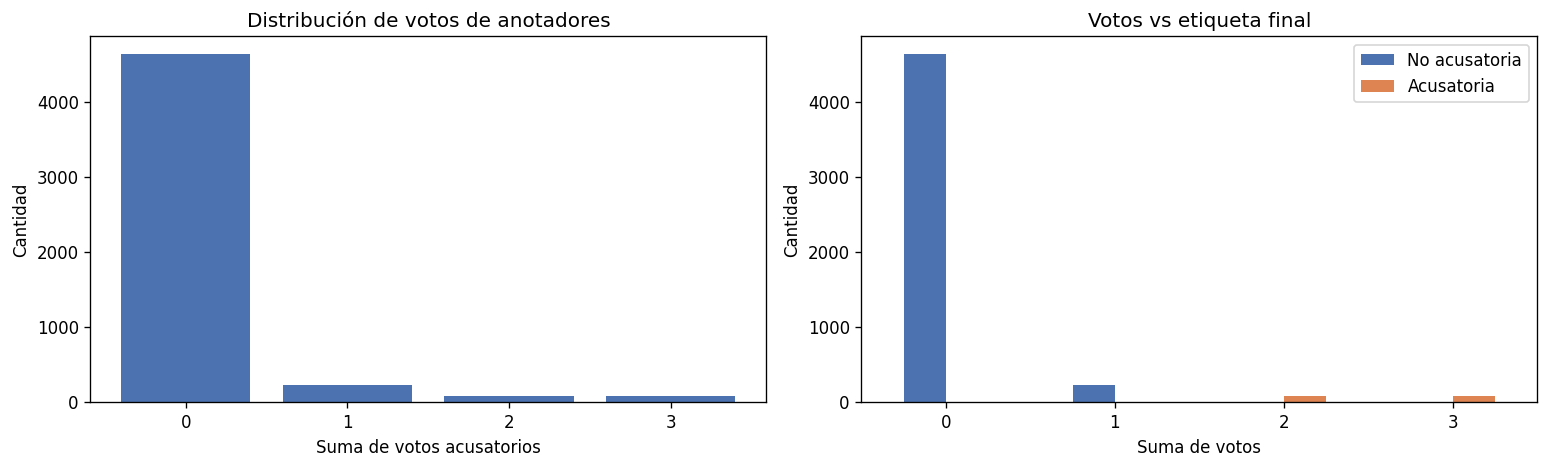

In [5]:
print("Valores únicos de suma de votos:", sorted(df[VOTES_COL].unique()))
print("\nTabla cruzada entre votos de anotadores y etiqueta final:")
display(pd.crosstab(df[VOTES_COL], df[TARGET], margins=True, margins_name="Total"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vote_counts = df[VOTES_COL].value_counts().sort_index()
axes[0].bar(vote_counts.index.astype(str), vote_counts.values, color="#4C72B0")
axes[0].set_title("Distribución de votos de anotadores")
axes[0].set_xlabel("Suma de votos acusatorios")
axes[0].set_ylabel("Cantidad")

cross = df.groupby([VOTES_COL, TARGET]).size().unstack(fill_value=0)
cross.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Votos vs etiqueta final")
axes[1].set_xlabel("Suma de votos")
axes[1].set_ylabel("Cantidad")
axes[1].legend(["No acusatoria", "Acusatoria"])
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [6]:
duplicados_texto = int(df[TEXT_COL].duplicated().sum())
duplicados_total = int(df.duplicated().sum())
labels_por_texto = df.groupby(TEXT_COL)[TARGET].nunique()
contradictorios = int((labels_por_texto > 1).sum())

print(f"Duplicados exactos en columna '{TEXT_COL}': {duplicados_texto}")
print(f"Filas completamente duplicadas: {duplicados_total}")
print(f"Textos duplicados con etiquetas contradictorias: {contradictorios}")

if duplicados_texto > 0:
    ejemplos = df[df[TEXT_COL].duplicated(keep=False)].sort_values(TEXT_COL).head(8)
    display(ejemplos[[TEXT_COL, TARGET, VOTES_COL]])

Duplicados exactos en columna 'pregunta': 147
Filas completamente duplicadas: 2
Textos duplicados con etiquetas contradictorias: 0


,pregunta,final_pregunta_isAcusatoria,sum_pregunta_isAcusatoria
2854,1 ) Es necesario entregar las herramientas? 2)...,0,0
3957,1 ) Es necesario entregar las herramientas? 2)...,0,0
658,"1 ) ¿Es necesario entregar papel higiénico, ja...",0,0
4553,"1 ) ¿Es necesario entregar papel higiénico, ja...",0,0
2545,1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a ...,0,1
2262,1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a ...,0,0
2814,1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a ...,0,0
1014,1. ES OBLIGATORIA LA VISITA TÉCNICA? 2. Van a ...,0,0


## 3. Preprocesamiento

Se normaliza el texto a minúsculas, se eliminan símbolos no informativos y se remueven stopwords en español. Se conservan negaciones e interrogativos porque pueden aportar señal semántica para detectar acusación. Luego se eliminan duplicados por texto limpio antes del split para evitar que la misma pregunta aparezca simultáneamente en entrenamiento y prueba.

In [7]:
# PROMPT usado con ChatGPT:
# "Genera una función de preprocesamiento para texto en español que preserve acentos,
# ñ, números, negaciones e interrogativos útiles; elimina duplicados antes del split y
# realiza un train/test split estratificado 80/20."

STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "con", "contra", "de", "del", "desde",
    "donde", "durante", "e", "el", "ella", "ellas", "ellos", "en", "entre", "era", "eran", "eras",
    "eres", "es", "esa", "esas", "ese", "eso", "esos", "esta", "estaba", "estaban", "estado", "estados",
    "estamos", "estar", "estas", "este", "esto", "estos", "estoy", "fue", "fueron", "fui", "fuimos",
    "ha", "han", "has", "he", "hemos", "la", "las", "le", "les", "lo", "los", "mas", "me", "mi",
    "mis", "mucho", "muchos", "muy", "nada", "nos", "nosotros", "nuestra", "nuestro", "o", "os", "otra",
    "otras", "otro", "otros", "para", "poco", "su", "sus", "tambien", "tanto", "te", "teneis", "tenemos",
    "tiene", "tienen", "tienes", "todo", "todos", "tu", "tus", "un", "una", "uno", "unos", "vosotros", "y", "ya", "yo"
}
KEEP_WORDS = {"no", "ni", "nunca", "jamás", "jamas", "tampoco", "sin", "cómo", "como", "cuándo", "cuando", "por", "qué", "que", "cuál", "cual", "hasta", "se", "si", "puede", "debe", "pero", "aunque"}
STOPWORDS_ES = STOPWORDS_ES - KEEP_WORDS


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [tok for tok in text.split() if tok not in STOPWORDS_ES]
    return " ".join(tokens)


df_clean = df.copy()
df_clean["pregunta_clean"] = df_clean[TEXT_COL].map(clean_text)
antes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="pregunta_clean").reset_index(drop=True)
duplicados_removidos = antes - len(df_clean)

X = df_clean["pregunta_clean"]
y = df_clean[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Filas originales: {antes}")
print(f"Filas tras eliminar duplicados por texto limpio: {len(df_clean)}")
print(f"Duplicados removidos: {duplicados_removidos}")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Positivos en train: {int(y_train.sum())} ({y_train.mean():.2%})")
print(f"Positivos en test: {int(y_test.sum())} ({y_test.mean():.2%})")

display(df_clean[[TEXT_COL, "pregunta_clean", TARGET]].head(10))

Filas originales: 5005
Filas tras eliminar duplicados por texto limpio: 4844
Duplicados removidos: 161
Train: 3875 | Test: 969
Positivos en train: 114 (2.94%)
Positivos en test: 29 (2.99%)


,pregunta,pregunta_clean,final_pregunta_isAcusatoria
0,Por favor requerimos se entregue un diagrama d...,por favor requerimos se entregue diagrama red ...,0
1,Indique de manera detallada y de manera taxati...,indique manera detallada manera taxativa decir...,0
2,4.En el punto 6 Información que dispone la ent...,4 punto 6 información que dispone entidad se h...,0
3,Se puede ofertar un equipo que utilice cubetas...,se puede ofertar equipo que utilice cubetas de...,0
4,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,podriann subir imagen spaguetti espiral grande,0
5,"Estimados señores, lastimosamente el presupues...",estimados señores lastimosamente presupuesto c...,0
6,Estimados en las especificaciones técnicas vie...,estimados especificaciones técnicas viene indi...,0
7,"ESTIMADOS, ESTABLECER EL LUGAR DE ENTREGA DE L...",estimados establecer lugar entrega productos g...,0
8,Lourdes Fashion le saluda cordialmente y al mi...,lourdes fashion saluda cordialmente mismo tiem...,0
9,"SALUDOS CORDIALES, ESTIMADOS SEÑORES PODRIAN C...",saludos cordiales estimados señores podrian co...,0


## 4. Feature extraction y t-SNE antes de clasificar

Para datos de texto se usa TF-IDF como extracción de características. La visualización t-SNE se calcula antes de entrenar clasificadores y solamente sobre el conjunto de entrenamiento. La etiqueta se usa únicamente para colorear los puntos, no para construir la proyección.

t-SNE calculado sobre 1500 textos de entrenamiento en 10.5 segundos


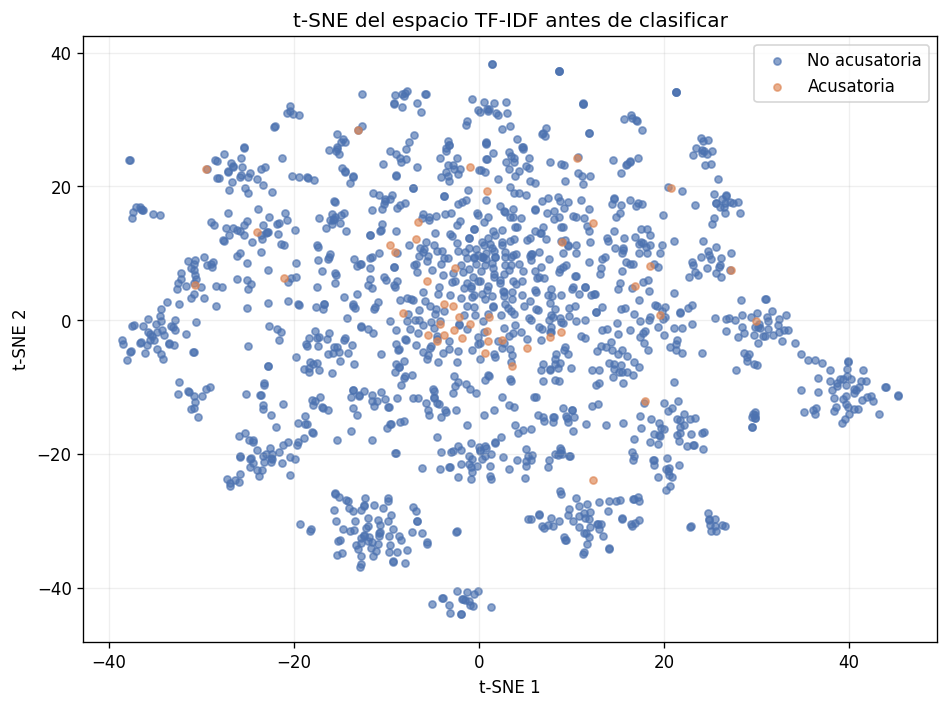

In [8]:
# PROMPT usado con ChatGPT:
# "Genera una visualización t-SNE antes de la clasificación usando TF-IDF y colorea por label,
# asegurando que solo se use el conjunto de entrenamiento para evitar data leakage."

max_samples = 1500
if len(X_train) > max_samples:
    X_tsne, _, y_tsne, _ = train_test_split(
        X_train, y_train, train_size=max_samples, stratify=y_train, random_state=RANDOM_STATE
    )
else:
    X_tsne, y_tsne = X_train, y_train

tsne_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=3000)
X_vec_tsne = tsne_vectorizer.fit_transform(X_tsne)
svd_components = max(2, min(50, X_vec_tsne.shape[0] - 1, X_vec_tsne.shape[1] - 1))
X_svd_tsne = TruncatedSVD(n_components=svd_components, random_state=RANDOM_STATE).fit_transform(X_vec_tsne)
perplexity = min(30, max(5, (len(X_tsne) - 1) // 3))

start = time.time()
tsne = TSNE(n_components=2, perplexity=perplexity, init="pca", learning_rate="auto", random_state=RANDOM_STATE)
coords = tsne.fit_transform(X_svd_tsne)
print(f"t-SNE calculado sobre {len(X_tsne)} textos de entrenamiento en {time.time() - start:.1f} segundos")

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "#4C72B0", "No acusatoria"), (1, "#DD8452", "Acusatoria")]:
    mask = y_tsne.to_numpy() == label
    ax.scatter(coords[mask, 0], coords[mask, 1], s=18, alpha=0.65, c=color, label=name)
ax.set_title("t-SNE del espacio TF-IDF antes de clasificar")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Pipelines, feature selection y modelos

Se usan `Pipeline` de sklearn para encapsular extracción TF-IDF, selección de características tipo filtro y clasificador. La selección `SelectKBest(chi2)` queda dentro del pipeline, por lo que se ajusta únicamente con los datos de entrenamiento de cada fold.

Modelos comparados:

1. Regresión Logística regularizada con `class_weight='balanced'`.
2. SVM lineal (`LinearSVC`) con `class_weight='balanced'`.

In [9]:
# PROMPT usado con ChatGPT:
# "Crea dos pipelines de sklearn para texto: TF-IDF + SelectKBest chi2 + LogisticRegression
# regularizada, y TF-IDF + SelectKBest chi2 + LinearSVC. Usa class_weight='balanced'."

pipeline_logreg = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("select", SelectKBest(score_func=chi2)),
    ("clf", LogisticRegression(solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE, max_iter=3000)),
])

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("select", SelectKBest(score_func=chi2)),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000, dual="auto")),
])

common_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.90],
    "select__k": [1000, 3000, "all"],
}
param_grid_logreg = {**common_grid, "clf__C": [0.1, 1.0, 10.0]}
param_grid_svm = {**common_grid, "clf__C": [0.01, 0.1, 1.0, 10.0]}

scoring = {
    "roc_auc": "roc_auc",
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "accuracy": "accuracy",
}

display(pipeline_logreg)
display(pipeline_svm)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 6. Optimización de hiperparámetros

La optimización usa `RepeatedStratifiedKFold` con 5 folds y 2 repeticiones para reducir costo computacional. Esto es consistente con la indicación de usar menos repeticiones si 10x10 resulta costoso. Luego, la comparación estadística final sí se realiza con 10 folds y 10 repeticiones sobre los modelos ya optimizados.

Tiempo optimizaci?n LogReg: 46.0 segundos
Mejores par?metros LogReg: {'clf__C': 10.0, 'select__k': 3000, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Mejor AUC-ROC CV tuning: 0.9440


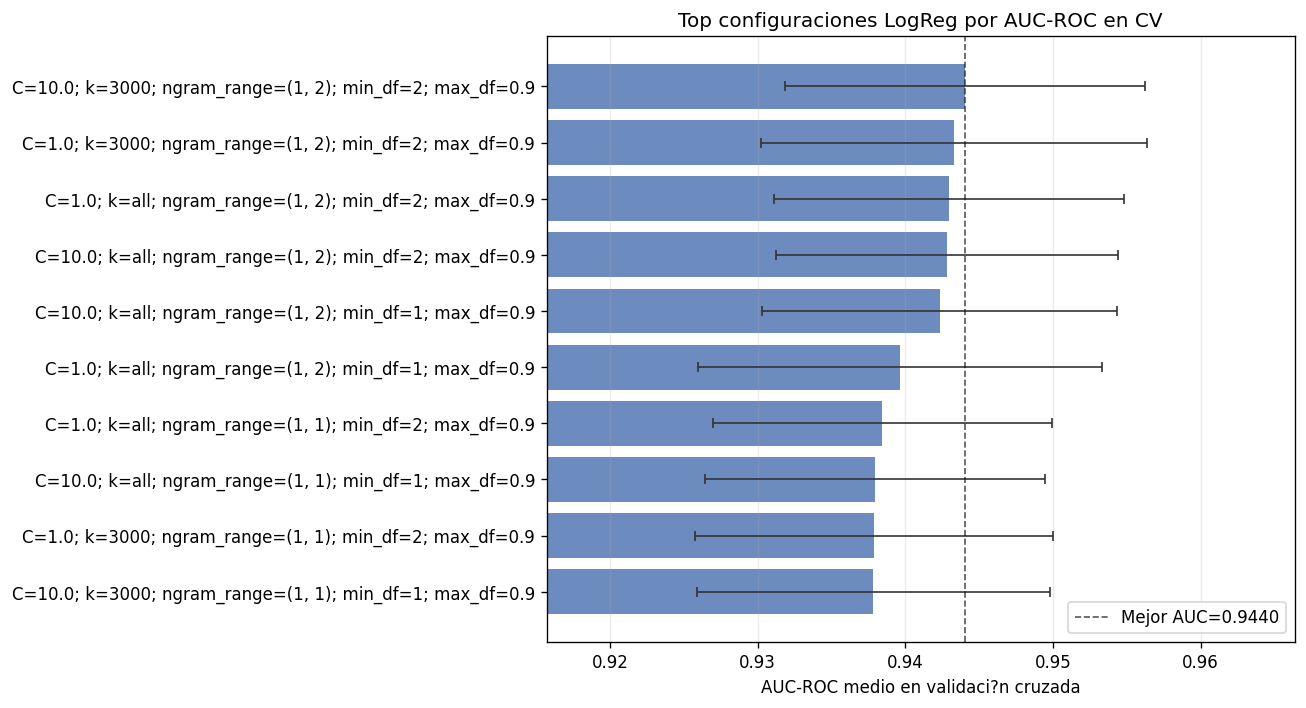

,rank,mean_auc,std_auc,configuraci?n
0,1,0.944047,0.012210,"C=10.0; k=3000; ngram_range=(1, 2); min_df=2; ..."
1,2,0.943317,0.013053,"C=1.0; k=3000; ngram_range=(1, 2); min_df=2; m..."
2,3,0.942994,0.011847,"C=1.0; k=all; ngram_range=(1, 2); min_df=2; ma..."
3,4,0.942845,0.011576,"C=10.0; k=all; ngram_range=(1, 2); min_df=2; m..."
4,5,0.942327,0.012044,"C=10.0; k=all; ngram_range=(1, 2); min_df=1; m..."
5,6,0.939640,0.013696,"C=1.0; k=all; ngram_range=(1, 2); min_df=1; ma..."
6,7,0.938441,0.011486,"C=1.0; k=all; ngram_range=(1, 1); min_df=2; ma..."
7,8,0.937979,0.011512,"C=10.0; k=all; ngram_range=(1, 1); min_df=1; m..."
8,9,0.937864,0.012132,"C=1.0; k=3000; ngram_range=(1, 1); min_df=2; m..."
9,10,0.937840,0.011958,"C=10.0; k=3000; ngram_range=(1, 1); min_df=1; ..."


In [ ]:
# PROMPT usado con ChatGPT:
# "Optimiza la regresi?n log?stica regularizada con GridSearchCV usando repeated k-fold CV.
# Muestra un ranking claro de las mejores combinaciones
# de hiperpar?metros por AUC-ROC con su variabilidad entre folds."

cv_tuning = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)


def summarize_grid_results(grid, top_n=10):
    results = pd.DataFrame(grid.cv_results_).copy()
    param_cols = [c for c in results.columns if c.startswith("param_")]
    results = results.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
    rows = []
    for rank, (_, row) in enumerate(results.head(top_n).iterrows(), start=1):
        params = {col.replace("param_", ""): row[col] for col in param_cols}
        label_parts = []
        for key in ["clf__C", "select__k", "tfidf__ngram_range", "tfidf__min_df", "tfidf__max_df", "features__word__ngram_range", "features__char__ngram_range"]:
            if key in params:
                short = key.replace("clf__", "").replace("select__", "").replace("tfidf__", "").replace("features__word__", "word_").replace("features__char__", "char_")
                label_parts.append(f"{short}={params[key]}")
        rows.append({
            "rank": rank,
            "mean_auc": row["mean_test_score"],
            "std_auc": row["std_test_score"],
            "configuraci?n": "; ".join(label_parts),
            **params,
        })
    return pd.DataFrame(rows)


def plot_top_grid_results(grid, title, color="#4C72B0", top_n=10):
    top = summarize_grid_results(grid, top_n=top_n)
    plot_df = top.iloc[::-1].copy()
    fig, ax = plt.subplots(figsize=(11, 6))
    y_pos = np.arange(len(plot_df))
    ax.barh(y_pos, plot_df["mean_auc"], color=color, alpha=0.82)
    ax.errorbar(plot_df["mean_auc"], y_pos, xerr=plot_df["std_auc"], fmt="none", ecolor="#333333", capsize=3, linewidth=1)
    ax.set_yticks(y_pos, plot_df["configuraci?n"])
    ax.set_xlabel("AUC-ROC medio en validaci?n cruzada")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    lower = max(0.5, float((plot_df["mean_auc"] - plot_df["std_auc"]).min()) - 0.01)
    upper = min(1.0, float((plot_df["mean_auc"] + plot_df["std_auc"]).max()) + 0.01)
    ax.set_xlim(lower, upper)
    best_auc = float(top.loc[0, "mean_auc"])
    ax.axvline(best_auc, color="#111111", linestyle="--", linewidth=1, alpha=0.7, label=f"Mejor AUC={best_auc:.4f}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    display(top[["rank", "mean_auc", "std_auc", "configuración"]])
    return top


start = time.time()
grid_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid_logreg,
    cv=cv_tuning,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
)
grid_logreg.fit(X_train, y_train)
print(f"Tiempo optimizaci?n LogReg: {time.time() - start:.1f} segundos")
print("Mejores parámetros LogReg:", grid_logreg.best_params_)
print(f"Mejor AUC-ROC CV tuning: {grid_logreg.best_score_:.4f}")

top_logreg = plot_top_grid_results(
    grid_logreg,
    "Top configuraciones LogReg por AUC-ROC en CV",
    color="#4C72B0",
    top_n=10,
)


AUC train final: 1.0000
AUC validación final: 0.9465
Gap train-validación: 0.0535


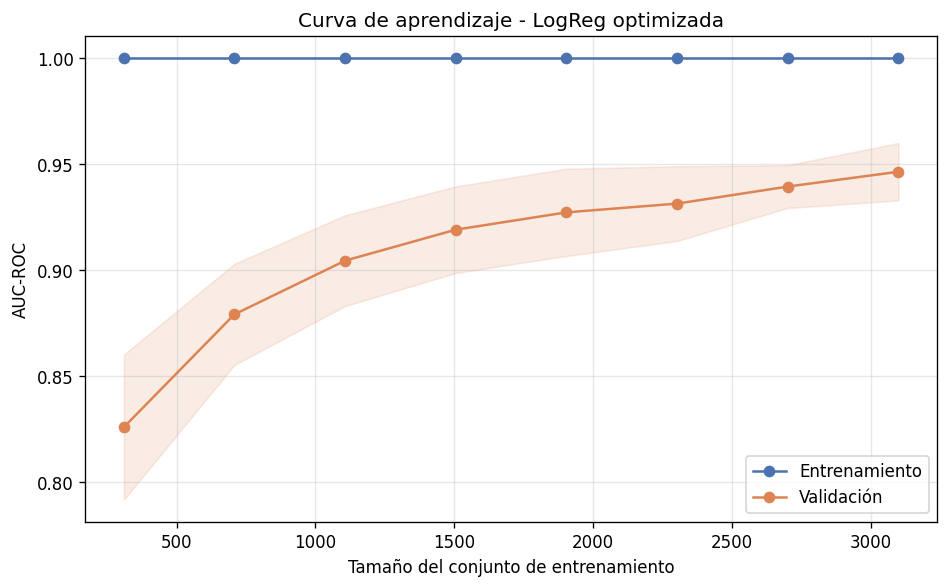

In [11]:
learning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    grid_logreg.best_estimator_,
    X_train,
    y_train,
    cv=learning_cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", label="Entrenamiento", color="#4C72B0")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_mean, "o-", label="Validación", color="#DD8452")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#DD8452")
ax.set_title("Curva de aprendizaje - LogReg optimizada")
ax.set_xlabel("Tamaño del conjunto de entrenamiento")
ax.set_ylabel("AUC-ROC")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC train final: {train_mean[-1]:.4f}")
print(f"AUC validación final: {val_mean[-1]:.4f}")
print(f"Gap train-validación: {train_mean[-1] - val_mean[-1]:.4f}")

Tiempo optimizaci?n LinearSVC: 46.6 segundos
Mejores par?metros LinearSVC: {'clf__C': 0.1, 'select__k': 3000, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Mejor AUC-ROC CV tuning: 0.9441


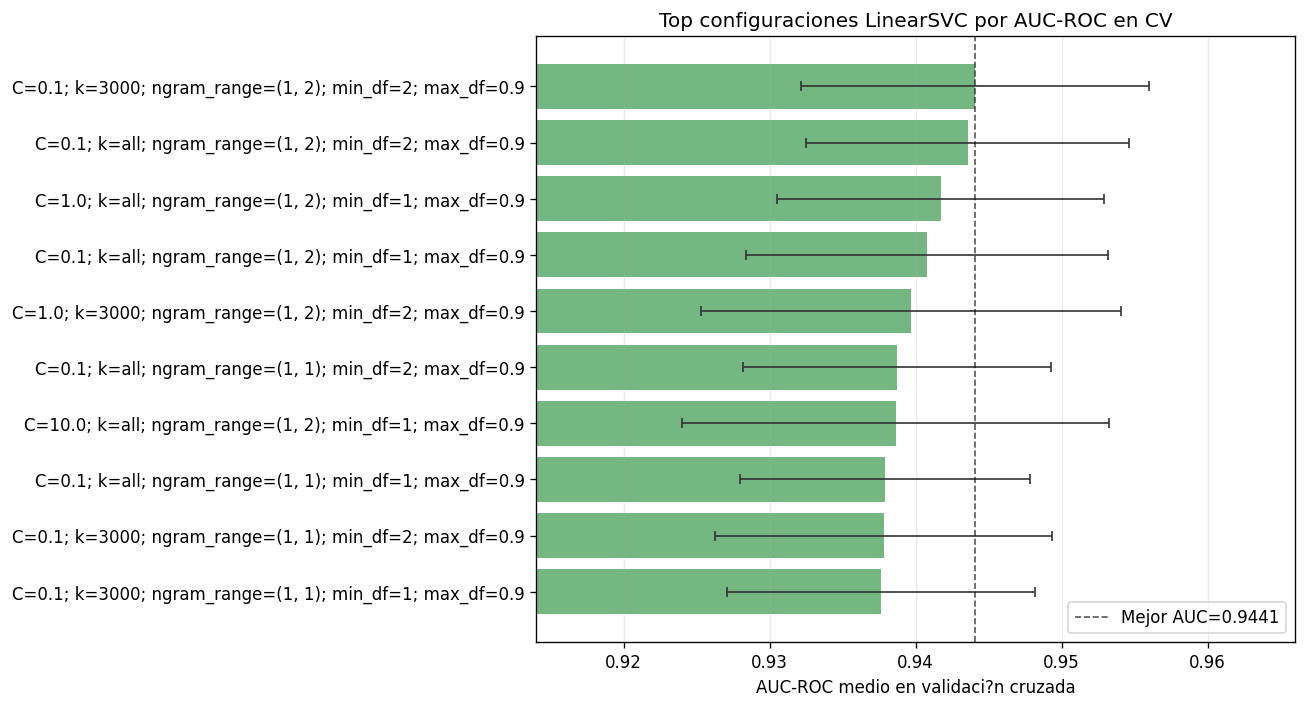

,rank,mean_auc,std_auc,configuraci?n
0,1,0.944066,0.011897,"C=0.1; k=3000; ngram_range=(1, 2); min_df=2; m..."
1,2,0.943566,0.011052,"C=0.1; k=all; ngram_range=(1, 2); min_df=2; ma..."
2,3,0.941708,0.011203,"C=1.0; k=all; ngram_range=(1, 2); min_df=1; ma..."
3,4,0.940800,0.012385,"C=0.1; k=all; ngram_range=(1, 2); min_df=1; ma..."
4,5,0.939689,0.014381,"C=1.0; k=3000; ngram_range=(1, 2); min_df=2; m..."
5,6,0.938723,0.010524,"C=0.1; k=all; ngram_range=(1, 1); min_df=2; ma..."
6,7,0.938626,0.014604,"C=10.0; k=all; ngram_range=(1, 2); min_df=1; m..."
7,8,0.937910,0.009910,"C=0.1; k=all; ngram_range=(1, 1); min_df=1; ma..."
8,9,0.937806,0.011538,"C=0.1; k=3000; ngram_range=(1, 1); min_df=2; m..."
9,10,0.937623,0.010548,"C=0.1; k=3000; ngram_range=(1, 1); min_df=1; m..."


In [12]:
# PROMPT usado con ChatGPT:
# "Optimiza un segundo modelo LinearSVC con GridSearchCV y repeated k-fold CV para poder
# compararlo estad?sticamente contra la regresi?n log?stica ya optimizada. Muestra un
# ranking de configuraciones en vez de una curva simple de regularizaci?n."

start = time.time()
grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=cv_tuning,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
)
grid_svm.fit(X_train, y_train)
print(f"Tiempo optimizaci?n LinearSVC: {time.time() - start:.1f} segundos")
print("Mejores par?metros LinearSVC:", grid_svm.best_params_)
print(f"Mejor AUC-ROC CV tuning: {grid_svm.best_score_:.4f}")

top_svm = plot_top_grid_results(
    grid_svm,
    "Top configuraciones LinearSVC por AUC-ROC en CV",
    color="#55A868",
    top_n=10,
)


## 7. Comparación estadística de 2 técnicas ML optimizadas

Se comparan los dos mejores estimadores ya optimizados usando `RepeatedStratifiedKFold(n_splits=10, n_repeats=10)`, lo que genera 100 pares de mediciones. La prueba principal es Wilcoxon pareada sobre AUC-ROC.

Hipótesis:

- H0: no hay diferencia en AUC-ROC entre los modelos optimizados.
- H1: existe diferencia en AUC-ROC entre los modelos optimizados.

In [13]:
# PROMPT usado con ChatGPT:
# "Realiza una comparación estadística entre dos modelos optimizados usando repeated
# 10-fold cross-validation y una prueba de Wilcoxon pareada sobre AUC-ROC."

cv_compare = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=RANDOM_STATE)

start = time.time()
cv_logreg = cross_validate(clone(grid_logreg.best_estimator_), X_train, y_train, cv=cv_compare, scoring=scoring, n_jobs=-1)
cv_svm = cross_validate(clone(grid_svm.best_estimator_), X_train, y_train, cv=cv_compare, scoring=scoring, n_jobs=-1)
print(f"Tiempo comparación 10x10: {time.time() - start:.1f} segundos")


def summarize_cv(cv_result):
    rows = []
    labels = {
        "roc_auc": "AUC-ROC",
        "f1_macro": "F1 macro",
        "precision_macro": "Precision macro",
        "recall_macro": "Recall macro",
        "accuracy": "Accuracy",
    }
    for key, label in labels.items():
        values = np.asarray(cv_result[f"test_{key}"])
        rows.append({"métrica": label, "media": values.mean(), "std": values.std(ddof=1)})
    return pd.DataFrame(rows)

summary_cv_logreg = summarize_cv(cv_logreg)
summary_cv_svm = summarize_cv(cv_svm)

auc_logreg = np.asarray(cv_logreg["test_roc_auc"])
auc_svm = np.asarray(cv_svm["test_roc_auc"])
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(auc_logreg, auc_svm, alternative="two-sided")
t_stat, t_p = stats.ttest_rel(auc_logreg, auc_svm)

stats_table = pd.DataFrame([
    {"comparación": "LogReg - LinearSVC", "media_diff_auc": (auc_logreg - auc_svm).mean(), "wilcoxon_stat": wilcoxon_stat, "wilcoxon_p": wilcoxon_p, "paired_t_stat": t_stat, "paired_t_p": t_p, "n_pares": len(auc_logreg)}
])

print("Resumen CV 10x10 - LogReg optimizada")
display(summary_cv_logreg)
print("Resumen CV 10x10 - LinearSVC optimizado")
display(summary_cv_svm)
print("Prueba estadística pareada")
display(stats_table)

alpha = 0.05
if wilcoxon_p < alpha:
    print(f"Con alpha={alpha}, se rechaza H0: hay diferencia estadísticamente significativa.")
else:
    print(f"Con alpha={alpha}, no se rechaza H0: no hay evidencia suficiente de diferencia significativa.")

Tiempo comparación 10x10: 16.2 segundos
Resumen CV 10x10 - LogReg optimizada
Resumen CV 10x10 - LinearSVC optimizado
Prueba estadística pareada
Con alpha=0.05, no se rechaza H0: no hay evidencia suficiente de diferencia significativa.


,métrica,media,std
0,AUC-ROC,0.942996,0.025481
1,F1 macro,0.691632,0.066117
2,Precision macro,0.741409,0.087173
3,Recall macro,0.667763,0.065799
4,Accuracy,0.969937,0.006672


,métrica,media,std
0,AUC-ROC,0.943303,0.025067
1,F1 macro,0.703735,0.051480
2,Precision macro,0.682465,0.050035
3,Recall macro,0.739870,0.067971
4,Accuracy,0.960414,0.008340


,comparación,media_diff_auc,wilcoxon_stat,wilcoxon_p,paired_t_stat,paired_t_p,n_pares
0,LogReg - LinearSVC,-0.000307,2234.0,0.400249,-0.588231,0.557717,100


## 8. Evaluación final en test

El conjunto de prueba se mantuvo separado durante optimización y comparación cruzada. Aqué se evalúan los modelos finales reentrenados con todo el conjunto de entrenamiento.

In [14]:
fitted_logreg = clone(grid_logreg.best_estimator_).fit(X_train, y_train)
fitted_svm = clone(grid_svm.best_estimator_).fit(X_train, y_train)

pred_logreg = fitted_logreg.predict(X_test)
pred_svm = fitted_svm.predict(X_test)
score_logreg = fitted_logreg.decision_function(X_test)
score_svm = fitted_svm.decision_function(X_test)

metrics_test = pd.DataFrame([
    {
        "modelo": "LogReg optimizada",
        "roc_auc": roc_auc_score(y_test, score_logreg),
        "f1_macro": f1_score(y_test, pred_logreg, average="macro", zero_division=0),
        "precision_macro": precision_score(y_test, pred_logreg, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred_logreg, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, pred_logreg),
    },
    {
        "modelo": "LinearSVC optimizado",
        "roc_auc": roc_auc_score(y_test, score_svm),
        "f1_macro": f1_score(y_test, pred_svm, average="macro", zero_division=0),
        "precision_macro": precision_score(y_test, pred_svm, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, pred_svm, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, pred_svm),
    },
])

display(metrics_test)

print("Reporte LogReg optimizada:")
print(classification_report(y_test, pred_logreg, target_names=["No acusatoria", "Acusatoria"], zero_division=0))
print("Reporte LinearSVC optimizado:")
print(classification_report(y_test, pred_svm, target_names=["No acusatoria", "Acusatoria"], zero_division=0))

Reporte LogReg optimizada:
               precision    recall  f1-score   support

No acusatoria       0.98      0.99      0.99       940
   Acusatoria       0.54      0.45      0.49        29

     accuracy                           0.97       969
    macro avg       0.76      0.72      0.74       969
 weighted avg       0.97      0.97      0.97       969

Reporte LinearSVC optimizado:
               precision    recall  f1-score   support

No acusatoria       0.99      0.98      0.98       940
   Acusatoria       0.45      0.62      0.52        29

     accuracy                           0.97       969
    macro avg       0.72      0.80      0.75       969
 weighted avg       0.97      0.97      0.97       969



,modelo,roc_auc,f1_macro,precision_macro,recall_macro,accuracy
0,LogReg optimizada,0.958291,0.738121,0.762368,0.718287,0.972136
1,LinearSVC optimizado,0.955576,0.752041,0.719080,0.798643,0.965944


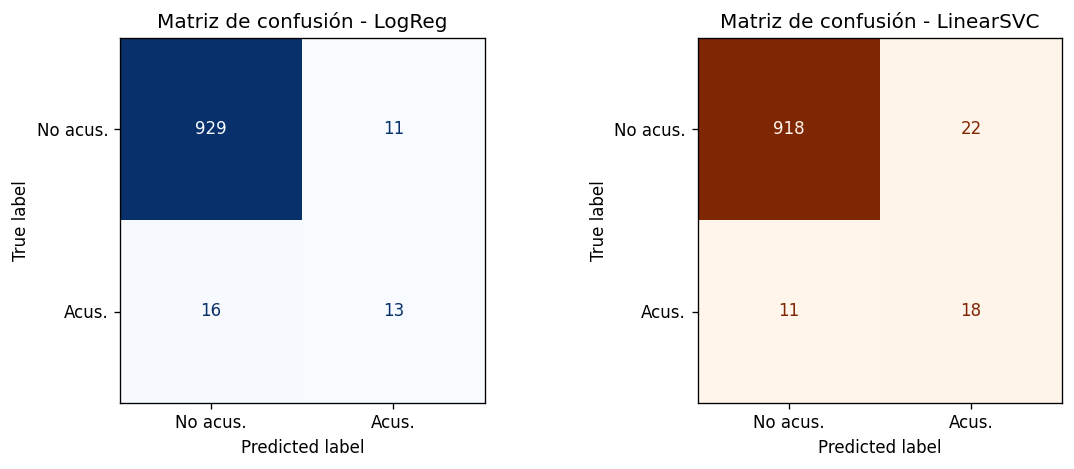

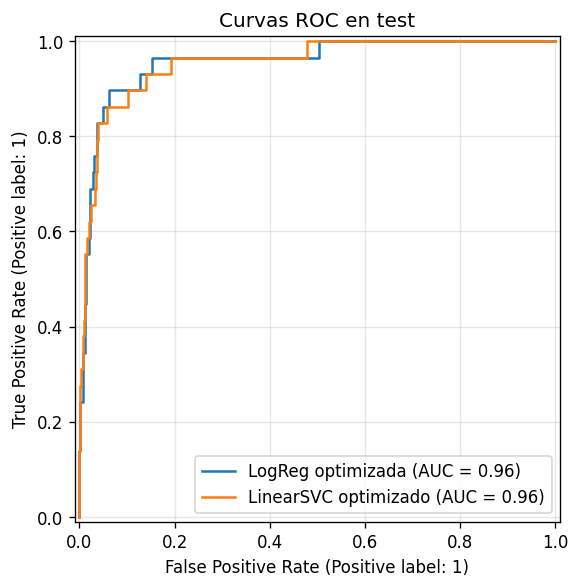

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, display_labels=["No acus.", "Acus."], cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Matriz de confusión - LogReg")
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm, display_labels=["No acus.", "Acus."], cmap="Oranges", colorbar=False, ax=axes[1])
axes[1].set_title("Matriz de confusión - LinearSVC")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(fitted_logreg, X_test, y_test, ax=ax, name="LogReg optimizada")
RocCurveDisplay.from_estimator(fitted_svm, X_test, y_test, ax=ax, name="LinearSVC optimizado")
ax.set_title("Curvas ROC en test")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8.1 Visualización t-SNE después de clasificar

Esta segunda visualización proyecta el espacio TF-IDF del conjunto de prueba después de entrenar el clasificador final. A diferencia del t-SNE previo, aquí los puntos se colorean con la clase predicha por el modelo `LinearSVC`, que fue el modelo más conveniente para priorizar la detección de comentarios acusatorios. Las marcas con borde negro corresponden a los casos realmente acusatorios, lo que permite inspeccionar visualmente falsos negativos y falsos positivos.

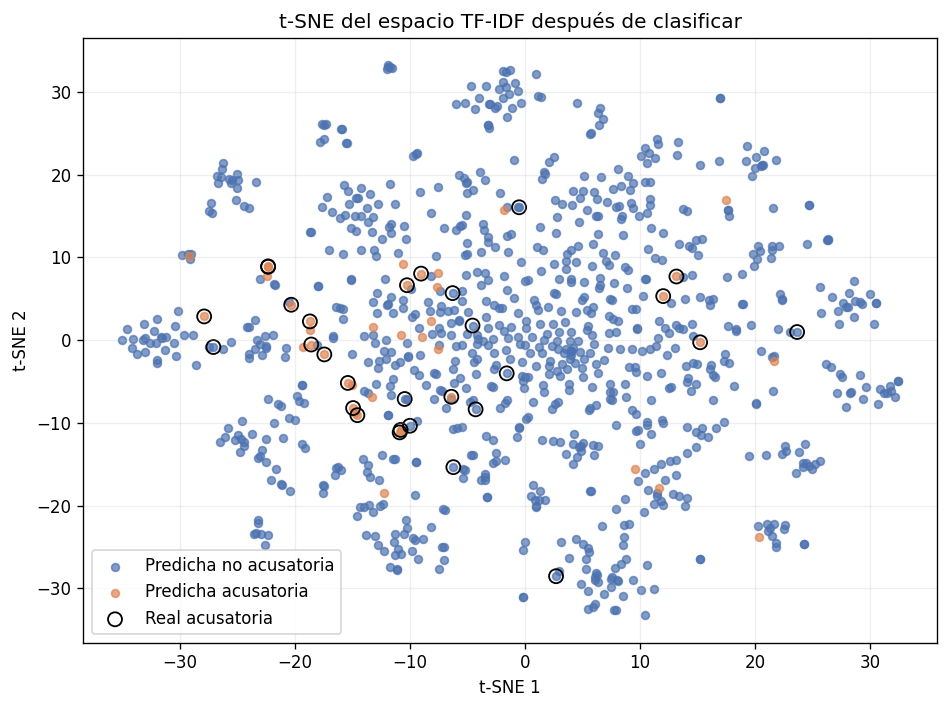

In [16]:
# PROMPT usado con ChatGPT:
# "Agrega una visualización t-SNE del espacio TF-IDF después de clasificar,
# usando el modelo entrenado para transformar el conjunto de prueba y coloreando por
# la etiqueta predicha. Mantén el test separado y no ajustes TF-IDF con todo el dataset."

# Se usa el pipeline final de LinearSVC porque prioriza mejor el recall de la clase acusatoria.
X_test_tfidf = fitted_svm.named_steps["tfidf"].transform(X_test)
X_test_selected = fitted_svm.named_steps["select"].transform(X_test_tfidf)

n_components_post = max(2, min(50, X_test_selected.shape[0] - 1, X_test_selected.shape[1] - 1))
X_test_svd = TruncatedSVD(n_components=n_components_post, random_state=RANDOM_STATE).fit_transform(X_test_selected)
perplexity_post = min(30, max(5, (X_test_svd.shape[0] - 1) // 3))
tsne_post = TSNE(n_components=2, perplexity=perplexity_post, init="pca", learning_rate="auto", random_state=RANDOM_STATE)
coords_post = tsne_post.fit_transform(X_test_svd)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "#4C72B0", "Predicha no acusatoria"), (1, "#DD8452", "Predicha acusatoria")]:
    mask = pred_svm == label
    ax.scatter(coords_post[mask, 0], coords_post[mask, 1], s=22, alpha=0.70, c=color, label=name)

real_positive = y_test.to_numpy() == 1
ax.scatter(coords_post[real_positive, 0], coords_post[real_positive, 1], s=70, facecolors="none", edgecolors="black", linewidths=1.1, label="Real acusatoria")
ax.set_title("t-SNE del espacio TF-IDF después de clasificar")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
# Términos más relevantes por chi2 en el pipeline final de LogReg.
tfidf = fitted_logreg.named_steps["tfidf"]
selector = fitted_logreg.named_steps["select"]
terms = np.asarray(tfidf.get_feature_names_out())
scores = selector.scores_
selected_mask = selector.get_support()
terms_selected = terms[selected_mask]
scores_selected = scores[selected_mask]
order = np.argsort(scores_selected)[::-1][:20]
top_terms = pd.DataFrame({"término": terms_selected[order], "chi2": scores_selected[order]})
display(top_terms)

,término,chi2
0,transparencia,26.621401
1,se supone,25.779332
2,supone que,25.779332
3,justo,23.328441
4,pierdan,22.886393
5,no pierdan,22.886393
6,direccionamiento,22.315258
7,supone,21.953330
8,hasta cuando,21.943917
9,casa comercial,21.299975


## 9. Revisión de data leakage

La revisión del flujo no muestra una fuga directa de información hacia los modelos. El conjunto de prueba se separa una sola vez mediante un split estratificado 80/20 y no participa en la optimización de hiperparámetros ni en la comparación estadística. Tanto la extracción TF-IDF como la selección de características `SelectKBest(chi2)` están dentro de objetos `Pipeline`, por lo que se ajustan únicamente con los datos de entrenamiento correspondientes en cada fold de validación cruzada, en lugar de ajustarse con todo el dataset antes de validar.

También se evitó usar variables que podrían introducir información artificial sobre la etiqueta. La columna `sum_pregunta_isAcusatoria` no se incluye como entrada del modelo porque proviene de los votos de anotadores y está directamente relacionada con `final_pregunta_isAcusatoria`. Del mismo modo, `contract_id` y `pregunta_id` se excluyen porque son identificadores y podrían inducir patrones espurios sin aportar contenido lingüístico real. Los duplicados se eliminan antes del split usando el texto limpio, lo que reduce el riesgo de que una misma pregunta aparezca simultáneamente en entrenamiento y prueba. Finalmente, la visualización t-SNE se calcula antes de entrenar clasificadores y solo con datos de entrenamiento; las etiquetas se usan únicamente para colorear la gráfica y facilitar la interpretación visual.

## 10. Conclusiones

El dataset presenta un desbalance fuerte, ya que las preguntas acusatorias representan una proporción pequeña de los registros. Por esa razón, la exactitud por sí sola no es suficiente para juzgar el desempeño del modelo; es más informativo observar AUC-ROC, F1 macro, recall macro y el reporte específico de la clase acusatoria. El uso de particiones estratificadas y `class_weight='balanced'` ayuda a que los modelos no ignoren completamente la clase minoritaria.

Los resultados indican que los modelos sí capturan señal útil en el texto. Ambos alcanzan AUC-ROC cercano a 0.95, lo que sugiere buena capacidad de ranking entre comentarios acusatorios y no acusatorios. Sin embargo, el rendimiento sobre la clase acusatoria todavía es moderado: el modelo LinearSVC logra mejor recall para acusatorios que la regresión logística, aunque a costa de más falsos positivos. Esto lo hace más apropiado como herramienta de priorización para revisión humana que como sistema automático definitivo.

La comparación estadística con repeated 10-fold cross-validation muestra desempeños muy parecidos entre Regresión Logística y LinearSVC. Como no se rechaza la hipótesis nula al nivel de significancia de 0.05, no hay evidencia suficiente para afirmar que uno de los dos modelos sea estadísticamente superior en AUC-ROC. En términos prácticos, LinearSVC puede preferirse si se busca detectar más casos acusatorios, mientras que Regresión Logística puede ser atractiva si se desea un modelo más interpretable y con menos falsos positivos.

## 11. Referencias

[1] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825-2830, 2011.

[2] G. Salton and C. Buckley, "Term-weighting approaches in automatic text retrieval," *Information Processing & Management*, vol. 24, no. 5, pp. 513-523, 1988.

[3] L. van der Maaten and G. Hinton, "Visualizing Data using t-SNE," *Journal of Machine Learning Research*, vol. 9, pp. 2579-2605, 2008.

[4] F. Wilcoxon, "Individual comparisons by ranking methods," *Biometrics Bulletin*, vol. 1, no. 6, pp. 80-83, 1945.

[5] C.-C. Chang and C.-J. Lin, "LIBSVM: A library for support vector machines," *ACM Transactions on Intelligent Systems and Technology*, vol. 2, no. 3, pp. 1-27, 2011.

[6] OpenAI, "ChatGPT prompts used for code assistance," prompts included as Python comments in the corresponding notebook cells, 2026.